<a href="https://colab.research.google.com/github/Turtl2718/ML/blob/ML/gsk3b_ecfp_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GSK3B QSAR Benchmark — ECFP4 vs ECFP6
## Morgan Fingerprint Radius Comparison across 4 Regression Models

**Target protein:** GSK3B (UniProt P49841)  
**Task:** Predict pIC50 from molecular structure  
**Key question:** Does ECFP6 (radius=3) outperform ECFP4 (radius=2) on this dataset?

---
### Pipeline overview
```
BindingDB (GSK3B entries)
    ↓ Clean & filter (remove inequality operators, aggregate duplicates)
    ↓ Compute pIC50 = -log10(IC50_nM × 1e-9)
    ↓ Featurize: ECFP4 (r=2, 2048 bits) vs ECFP6 (r=3, 2048 bits)
    ↓ Train: LGBM · Random Forest · Ridge · XGBoost
    ↓ Evaluate: R², RMSE, MAE, Pearson r (+ ROC-AUC secondary)
    ↓ Apply: Score virtual/unlabeled library → rank by predicted pIC50
```


---
## Section 1 — Setup & Imports

We install and import everything needed. The key libraries are:
- **RDKit** — cheminformatics: SMILES parsing, fingerprint generation
- **LightGBM** — gradient boosted trees, fast and accurate on tabular data
- **scikit-learn** — Random Forest, Ridge, GBM, and all metrics
- **DuckDB** — fast SQL queries on our pre-converted BindingDB file


In [1]:
# ── Colab installation (skip if running lhttps://github.com/Turtl2718/ML/raw/refs/heads/ML/gsk3b_3526_entries.ddbocally with env already set up) ──
try:
    import google.colab
    !uv pip install rdkit duckdb pandas numpy seaborn matplotlib \
                    scikit-learn lightgbm scipy tqdm useful_rdkit_utils -q
except ImportError:
    pass  # Already installed locally


In [2]:
import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import duckdb
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, roc_auc_score)
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor

print("All imports OK ✓")


All imports OK ✓


---
## Section 2 — Load & Clean BindingDB Data

We connect to the pre-built DuckDB file and pull all GSK3B entries.

### Why we clean the data
- IC50 values with `>` or `<` operators (e.g. `>10000`) are **censored** —
  we don't know the true value, only a bound. Including them would bias the model.
- Duplicate ligands measured in multiple assays are **averaged** (mean pIC50),
  since biological assays have inherent variability (~0.3–0.5 log units).


In [3]:
UNIPROT_ID = "P49841"  # GSK3B
DB_PATH    = Path("gsk3b_14000_entries.ddb")  # adjust path if needed

con = duckdb.connect(DB_PATH)

query = f"""
    SELECT
        "Ligand SMILES",
        "Ligand InChI Key",
        "BindingDB Ligand Name",
        "Target Source Organism According to Curator or DataSource",
        "IC50 (nM)"
    FROM bindingdb
    WHERE "UniProt (SwissProt) Primary ID of Target Chain 1" = '{UNIPROT_ID}'
"""

raw_df = con.execute(query).df()
print(f"Raw entries pulled: {len(raw_df)}")
raw_df.head(3)


Raw entries pulled: 13919


,Ligand SMILES,Ligand InChI Key,BindingDB Ligand Name,Target Source Organism According to Curator or DataSource,IC50 (nM)
0,CN1CCN(CC1)S(=O)(=O)c1ccc(cc1)-c1cnc(N)c(n1)C(...,FHCSBLWRGCOVPT-UHFFFAOYSA-N,CHEMBL2177161,Homo sapiens,0.004000
1,Fc1cc2CN(CCn3cc(C4=C(C(=O)NC4=O)c4coc5ccccc45)...,ANVVOODAIJRKDL-UHFFFAOYSA-N,CHEMBL2386094,Homo sapiens,0.013000
2,CC(C)Oc1ccc(F)c(c1)-c1cnc(N)c(n1)C(=O)Nc1cnccc...,UZIATSFXNVOVFE-OAHLLOKOSA-N,CHEMBL4647659,Homo sapiens,None


In [4]:
raw_df

,Ligand SMILES,Ligand InChI Key,BindingDB Ligand Name,Target Source Organism According to Curator or DataSource,IC50 (nM)
0,CN1CCN(CC1)S(=O)(=O)c1ccc(cc1)-c1cnc(N)c(n1)C(...,FHCSBLWRGCOVPT-UHFFFAOYSA-N,CHEMBL2177161,Homo sapiens,0.004000
1,Fc1cc2CN(CCn3cc(C4=C(C(=O)NC4=O)c4coc5ccccc45)...,ANVVOODAIJRKDL-UHFFFAOYSA-N,CHEMBL2386094,Homo sapiens,0.013000
2,CC(C)Oc1ccc(F)c(c1)-c1cnc(N)c(n1)C(=O)Nc1cnccc...,UZIATSFXNVOVFE-OAHLLOKOSA-N,CHEMBL4647659,Homo sapiens,None
3,Cn1cc(C2=C(C(=O)NC2=O)c2cccc(NC[C@H](O)CO)c2)c...,RPGZQOOZHIEPJW-HNNXBMFYSA-N,CHEMBL1232189,Homo sapiens,None
4,Cn1cc(c2c1ccc(c2)F)C3=C(C(=O)NC3=O)c4cccc(c4)N...,RPGZQOOZHIEPJW-UHFFFAOYSA-N,"(R,S)-3-(3-(2,3-dihydroxypropylamino)phenyl)-4...",Homo sapiens,None
...,...,...,...,...,...
13914,CCCNC(=O)O[C@H]1CC[C@H](C1)c1cc(NC(=O)C2COc3cc...,SUUQWARTYWLJHY-UHFFFAOYSA-N,"US11014911, Example 24::US11014911, Example 25...",Homo sapiens,None
13915,OC(=O)c1cccc(NC2=C(C(=O)NC2=O)c2ccccc2Cl)c1 |t:9|,JETNNLCMZCYIJE-UHFFFAOYSA-N,"3-{[4-(2-chlorophenyl)-2,5-dioxo-2,5-dihydro-1...",Homo sapiens,136
13916,CSc1nc(c([nH]1)-c1ccnc(NC(=O)C2CCCC2)c1)-c1ccc...,KUDDBTSZCDPLGE-UHFFFAOYSA-N,CHEMBL4574237,Homo sapiens,136
13917,O=C1NC(=O)C2=C1c1cn(CCOCCOCCn3cc2c2ccccc32)c2c...,BIGPNLBOTAHTOI-UHFFFAOYSA-N,"17,20-dioxa-4,14,23-triazahexacyclo[21.6.1.17,...",Homo sapiens,136


In [5]:
# ── 1. Remove censored measurements (>, <) ──────────────────────────────────
raw_df["has_operator"] = raw_df["IC50 (nM)"].str.startswith((">", "<"))
clean_df = raw_df.query("`IC50 (nM)`.notna() and has_operator == False").copy()
print(f"After removing censored values: {len(clean_df)}")

# ── 2. Convert IC50 (nM) → pIC50 ────────────────────────────────────────────
# pIC50 = -log10(IC50_M) — converts nM to M first
# Higher pIC50 = more potent (pIC50 7 = IC50 100 nM)
clean_df["pIC50"] = -np.log10(clean_df["IC50 (nM)"].astype(float) * 1e-9)

# ── 3. Aggregate duplicates: same molecule measured multiple times ────────────
agg_list = []
for inchi_key, group in clean_df.groupby("Ligand InChI Key"):
    agg_list.append({
        "SMILES": group["Ligand SMILES"].values[0],
        "InChIKey": inchi_key,
        "pIC50": group["pIC50"].mean(),       # mean across assays
        "n_measurements": len(group)
    })

agg_df = pd.DataFrame(agg_list)
print(f"Unique molecules after aggregation: {len(agg_df)}")
print(f"pIC50 — mean: {agg_df.pIC50.mean():.2f}  std: {agg_df.pIC50.std():.2f}  "
      f"range: [{agg_df.pIC50.min():.1f}, {agg_df.pIC50.max():.1f}]")
agg_df.head()


After removing censored values: 4913
Unique molecules after aggregation: 3167
pIC50 — mean: 6.57  std: 1.29  range: [2.4, 10.9]


,SMILES,InChIKey,pIC50,n_measurements
0,C[C@@H]1CN(CCN1c1nc(cc(=O)n1C)-c1ccncn1)C(C)=O...,AABPPUNQWOHVKN-UHFFFAOYSA-N,7.309804,1
1,Nc1ncc(nc1C(=O)Nc1ncccc1N1CCC(N)(CO)CC1)-c1ncc...,AAKDVUMRVXYBST-UHFFFAOYSA-N,5.886057,1
2,COc1cccc(c1)-c1n[nH]c2c(N=NCc3ccncc3)ncnc12 |w...,AAOVCUZTOYSLHK-UHFFFAOYSA-N,8.300162,1
3,CC(C)C(=O)Nc1cc(ccn1)C(=O)Nc1cnccc1OCC(F)F,AASZBVWGEDIXLX-UHFFFAOYSA-N,8.744727,1
4,[H][C@]12OC[C@H](Nc3nccc(n3)-c3ccc(OC)cc3)[C@@...,ABBGHJJBHAIDHI-UHFFFAOYSA-N,7.060481,1


In [6]:
list(clean_df.columns)

['Ligand SMILES',
 'Ligand InChI Key',
 'BindingDB Ligand Name',
 'Target Source Organism According to Curator or DataSource',
 'IC50 (nM)',
 'has_operator',
 'pIC50']

In [7]:
raw_df.columns

Index(['Ligand SMILES', 'Ligand InChI Key', 'BindingDB Ligand Name',
       'Target Source Organism According to Curator or DataSource',
       'IC50 (nM)', 'has_operator'],
      dtype='object')

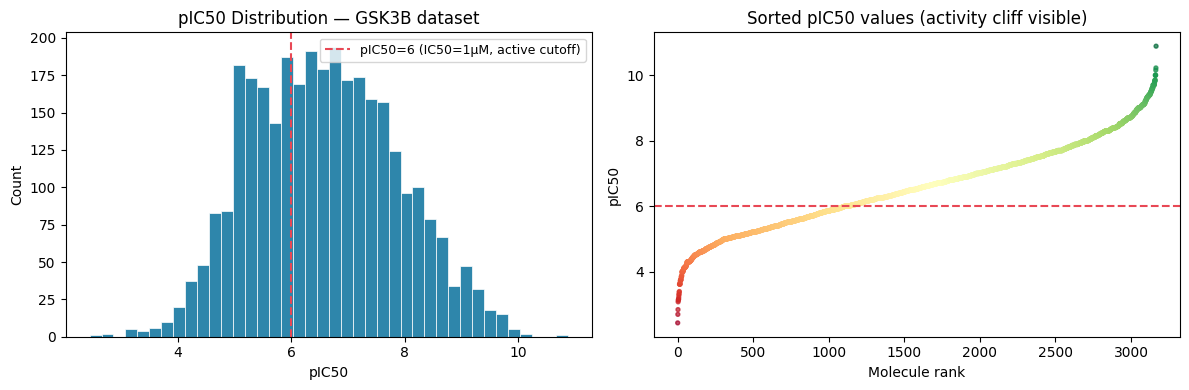

Molecules with pIC50 ≥ 6 (IC50 ≤ 1µM): 65.1%  ← used for ROC-AUC later


In [8]:
# ── pIC50 distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(agg_df.pIC50, bins=40, color='#2E86AB', edgecolor='white', linewidth=0.5)
axes[0].axvline(6, color='#E84855', ls='--', lw=1.5, label='pIC50=6 (IC50=1µM, active cutoff)')
axes[0].set_xlabel("pIC50"); axes[0].set_ylabel("Count")
axes[0].set_title("pIC50 Distribution — GSK3B dataset")
axes[0].legend(fontsize=9)

axes[1].scatter(range(len(agg_df)),
                agg_df.sort_values("pIC50").pIC50,
                c=agg_df.sort_values("pIC50").pIC50,
                cmap='RdYlGn', s=8, alpha=0.7)
axes[1].axhline(6, color='#E84855', ls='--', lw=1.5)
axes[1].set_xlabel("Molecule rank"); axes[1].set_ylabel("pIC50")
axes[1].set_title("Sorted pIC50 values (activity cliff visible)")

plt.tight_layout()
plt.show()

pct_active = (agg_df.pIC50 >= 6).mean() * 100
print(f"Molecules with pIC50 ≥ 6 (IC50 ≤ 1µM): {pct_active:.1f}%  ← used for ROC-AUC later")


---
## Section 3 — Fingerprint Generation: ECFP4 vs ECFP6

### What is a Morgan / ECFP fingerprint?

Morgan fingerprints (also called ECFPs) encode each molecule as a **bit vector**
where each bit represents the presence of a circular substructure around an atom.

```
Atom → look at neighbors → hash → set bit in vector
```

The **radius** controls how far out we look:

| Name | radius | Captures |
|------|--------|----------|
| ECFP2 | 1 | Immediate atom environment (atom + direct bonds) |
| **ECFP4** | **2** | **2-hop neighborhood — functional groups** |
| **ECFP6** | **3** | **3-hop neighborhood — slightly wider context** |
| ECFP8 | 4 | Rarely used — very long-range, high collision |

**Bit collision:** At 2048 bits, distinct substructures can share the same bit.
ECFP6 generates more unique substructures than ECFP4, so it has slightly
more collision at 2048 bits — but this is usually minor in practice.

We generate **both** and compare them head-to-head below.


In [9]:
def smiles_to_fp(smiles_series, radius, n_bits=2048):
    """Convert a pandas Series of SMILES to a numpy array of Morgan fingerprints."""
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = []
    valid_mask = []
    for smi in tqdm(smiles_series, desc=f"ECFP{radius*2} r={radius}", leave=False):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(gen.GetFingerprint(mol))
            valid_mask.append(True)
        else:
            fps.append(None)
            valid_mask.append(False)
    # Convert to numpy (only valid mols)
    valid_fps = [fp for fp in fps if fp is not None]
    X = np.zeros((len(valid_fps), n_bits), dtype=np.uint8)
    for i, fp in enumerate(valid_fps):
        X[i] = np.array(fp)
    return X, np.array(valid_mask)

# ── Generate ECFP4 (radius=2) ────────────────────────────────────────────────
X_ecfp4, mask4 = smiles_to_fp(agg_df.SMILES, radius=2, n_bits=2048)

# ── Generate ECFP6 (radius=3) ────────────────────────────────────────────────
X_ecfp6, mask6 = smiles_to_fp(agg_df.SMILES, radius=3, n_bits=2048)

# Use intersection of valid molecules from both
valid_mask = mask4 & mask6
y = agg_df.pIC50.values[valid_mask]

print(f"\nECFP4 shape: {X_ecfp4.shape}  (molecules × bits)")
print(f"ECFP6 shape: {X_ecfp6.shape}  (molecules × bits)")
print(f"Valid molecules: {valid_mask.sum()} / {len(agg_df)}")


ECFP4 r=2:   0%|          | 0/3167 [00:00<?, ?it/s]

ECFP6 r=3:   0%|          | 0/3167 [00:00<?, ?it/s]


ECFP4 shape: (3167, 2048)  (molecules × bits)
ECFP6 shape: (3167, 2048)  (molecules × bits)
Valid molecules: 3167 / 3167


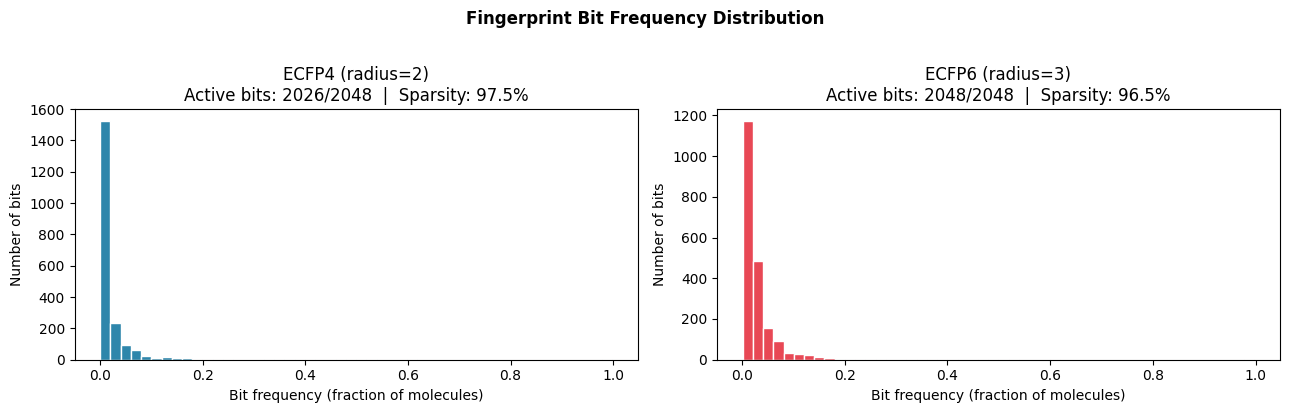

Interpretation:
  - More active bits in ECFP6 = captures more unique substructures
  - Higher sparsity in ECFP6 = each molecule is more uniquely encoded
  - But more unique substructures also means more potential bit collisions


In [10]:
# ── Fingerprint statistics comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, X, name, color in zip(axes,
                               [X_ecfp4, X_ecfp6],
                               ["ECFP4 (radius=2)", "ECFP6 (radius=3)"],
                               ["#2E86AB", "#E84855"]):
    bit_freq = X.mean(axis=0)  # frequency each bit is set across all molecules
    ax.hist(bit_freq[bit_freq > 0], bins=50, color=color, edgecolor='white', lw=0.4)
    n_active_bits = (bit_freq > 0).sum()
    sparsity = (X == 0).mean() * 100
    ax.set_title(f"{name}\nActive bits: {n_active_bits}/2048  |  Sparsity: {sparsity:.1f}%")
    ax.set_xlabel("Bit frequency (fraction of molecules)")
    ax.set_ylabel("Number of bits")

plt.suptitle("Fingerprint Bit Frequency Distribution", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - More active bits in ECFP6 = captures more unique substructures")
print("  - Higher sparsity in ECFP6 = each molecule is more uniquely encoded")
print("  - But more unique substructures also means more potential bit collisions")


---
## Section 4 — Train/Test Split

We use a **stratified random split** (80/20), stratifying by pIC50 quartile
so the activity distribution is preserved in both train and test sets.

> **Note for future work:** A *scaffold split* (splitting by Murcko scaffold)
> gives a more realistic estimate of how the model generalises to truly
> novel chemotypes. Random split is fine for a benchmark demo.


In [11]:
# Stratify by pIC50 quartile to preserve activity distribution
strat_labels = pd.qcut(y, q=4, labels=False)

(X4_train, X4_test,
 X6_train, X6_test,
 y_train,  y_test) = train_test_split(
    X_ecfp4, X_ecfp6, y,
    test_size=0.2, random_state=42, stratify=strat_labels
)

print(f"Train set: {len(y_train)} molecules")
print(f"Test set : {len(y_test)} molecules")
print(f"Train pIC50 mean: {y_train.mean():.2f}  |  Test pIC50 mean: {y_test.mean():.2f}")

# Scale fingerprints for Ridge (MaxAbsScaler keeps [0,1] range)
# Tree models (LGBM, RF, XGBoost) do NOT need scaling
scaler = MaxAbsScaler()
X4_train_sc = scaler.fit_transform(X4_train.astype(np.float32))
X4_test_sc  = scaler.transform(X4_test.astype(np.float32))

scaler6 = MaxAbsScaler()
X6_train_sc = scaler6.fit_transform(X6_train.astype(np.float32))
X6_test_sc  = scaler6.transform(X6_test.astype(np.float32))

print("\nScaling done (for Ridge only — tree models use raw binary fingerprints)")


Train set: 2533 molecules
Test set : 634 molecules
Train pIC50 mean: 6.58  |  Test pIC50 mean: 6.55

Scaling done (for Ridge only — tree models use raw binary fingerprints)


---
## Section 5 — Train All Models on ECFP4 and ECFP6

### Models and why we chose them

| Model | Type | Why include it |
|-------|------|----------------|
| **LGBM** | Gradient boosted trees | Fast, handles sparse fingerprints well, state-of-the-art on tabular data |
| **Random Forest** | Ensemble trees | Robust baseline, low variance, no hyperparameter sensitivity |
| **Ridge** | Linear + L2 reg | Simple, interpretable; shows if the problem is linearly separable |
| **XGBoost (GBR)** | Gradient boosted trees | Compare with LGBM; tends to need more tuning |

### Metrics we report

| Metric | Formula | What it means | Good value |
|--------|---------|---------------|------------|
| **R²** | 1 - SS_res/SS_tot | % variance explained | > 0.6 acceptable, > 0.7 good |
| **RMSE** | √mean((y-ŷ)²) | Avg error in pIC50 units | < 1.0 = good |
| **MAE** | mean(|y-ŷ|) | Less sensitive to outliers than RMSE | < 0.7 = good |
| **Pearson r** | corr(y, ŷ) | Linear correlation | > 0.8 = good |
| **ROC-AUC** | (classification) | Active/inactive ranking | > 0.8 = good |

> **ROC-AUC here:** We binarize pIC50 ≥ 6 as "active" and use the regression
> score as the ranking function. This shows how well the model separates actives
> from inactives even though it was trained as a regressor.


In [12]:
ACTIVE_CUTOFF = 6.0  # pIC50 ≥ 6 → active (IC50 ≤ 1µM)

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, is_scaled=False):
    """Train model and return full metrics dict."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    preds = model.predict(X_te)
    r2    = r2_score(y_te, preds)
    rmse  = mean_squared_error(y_te, preds) ** 0.5
    mae   = mean_absolute_error(y_te, preds)
    pearson_r = np.corrcoef(y_te, preds)[0, 1]

    # ROC-AUC: use predicted pIC50 as score; binarize true labels
    y_binary = (y_te >= ACTIVE_CUTOFF).astype(int)
    try:
        auc = roc_auc_score(y_binary, preds) if y_binary.sum() > 0 else float('nan')
    except Exception:
        auc = float('nan')

    return {
        "model": name,
        "preds": preds,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Pearson_r": pearson_r,
        "ROC_AUC": auc,
        "time_s": elapsed,
    }


all_results = {}  # all_results[fp_name][model_name] = metrics dict

# ── Models dict: (constructor, use_scaled_X) ─────────────────────────────────
MODELS = {
    "LGBM":          (LGBMRegressor(n_estimators=300, verbose=-1, random_state=42), False),
    "Random Forest": (RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), False),
    "Ridge":         (Ridge(alpha=1.0), True),
    "XGBoost (GBR)": (GradientBoostingRegressor(n_estimators=200, learning_rate=0.08,
                                                 max_depth=4, random_state=42), False),
}

FP_CONFIGS = {
    "ECFP4 (r=2)": (X4_train, X4_test, X4_train_sc, X4_test_sc),
    "ECFP6 (r=3)": (X6_train, X6_test, X6_train_sc, X6_test_sc),
}

print(f"{'':30s} {'R²':>6} {'RMSE':>6} {'MAE':>6} {'Pearson':>8} {'AUC':>6}  {'Time':>6}")
print("-" * 80)

for fp_name, (Xtr, Xte, Xtr_sc, Xte_sc) in FP_CONFIGS.items():
    all_results[fp_name] = {}
    print(f"\n── {fp_name} ──")
    for model_name, (model, use_scaled) in MODELS.items():
        import copy
        m = copy.deepcopy(model)
        Xtr_use = Xtr_sc if use_scaled else Xtr
        Xte_use = Xte_sc if use_scaled else Xte
        res = evaluate_model(model_name, m, Xtr_use, Xte_use, y_train, y_test)
        all_results[fp_name][model_name] = res
        print(f"  {model_name:26s} {res['R2']:6.3f} {res['RMSE']:6.3f} "
              f"{res['MAE']:6.3f} {res['Pearson_r']:8.3f} {res['ROC_AUC']:6.3f}  "
              f"{res['time_s']:5.1f}s")


                                   R²   RMSE    MAE  Pearson    AUC    Time
--------------------------------------------------------------------------------

── ECFP4 (r=2) ──
  LGBM                        0.689  0.713  0.522    0.830  0.910    0.9s
  Random Forest               0.672  0.731  0.531    0.820  0.903   56.5s
  Ridge                       0.471  0.929  0.695    0.726  0.851    0.7s
  XGBoost (GBR)               0.604  0.804  0.616    0.785  0.887   27.7s

── ECFP6 (r=3) ──
  LGBM                        0.670  0.734  0.526    0.819  0.906    1.2s
  Random Forest               0.668  0.736  0.534    0.819  0.909   68.9s
  Ridge                       0.360  1.022  0.764    0.698  0.832    0.4s
  XGBoost (GBR)               0.603  0.805  0.609    0.782  0.887   27.3s


---
## Section 6 — Results Visualization

Four panels:
1. **Predicted vs Actual** scatter plots — shows model behaviour and outliers
2. **Metric comparison heatmap** — quick read of ECFP4 vs ECFP6 for all models
3. **RMSE / MAE bar chart** — error magnitude comparison
4. **ROC-AUC** — active/inactive discrimination ability


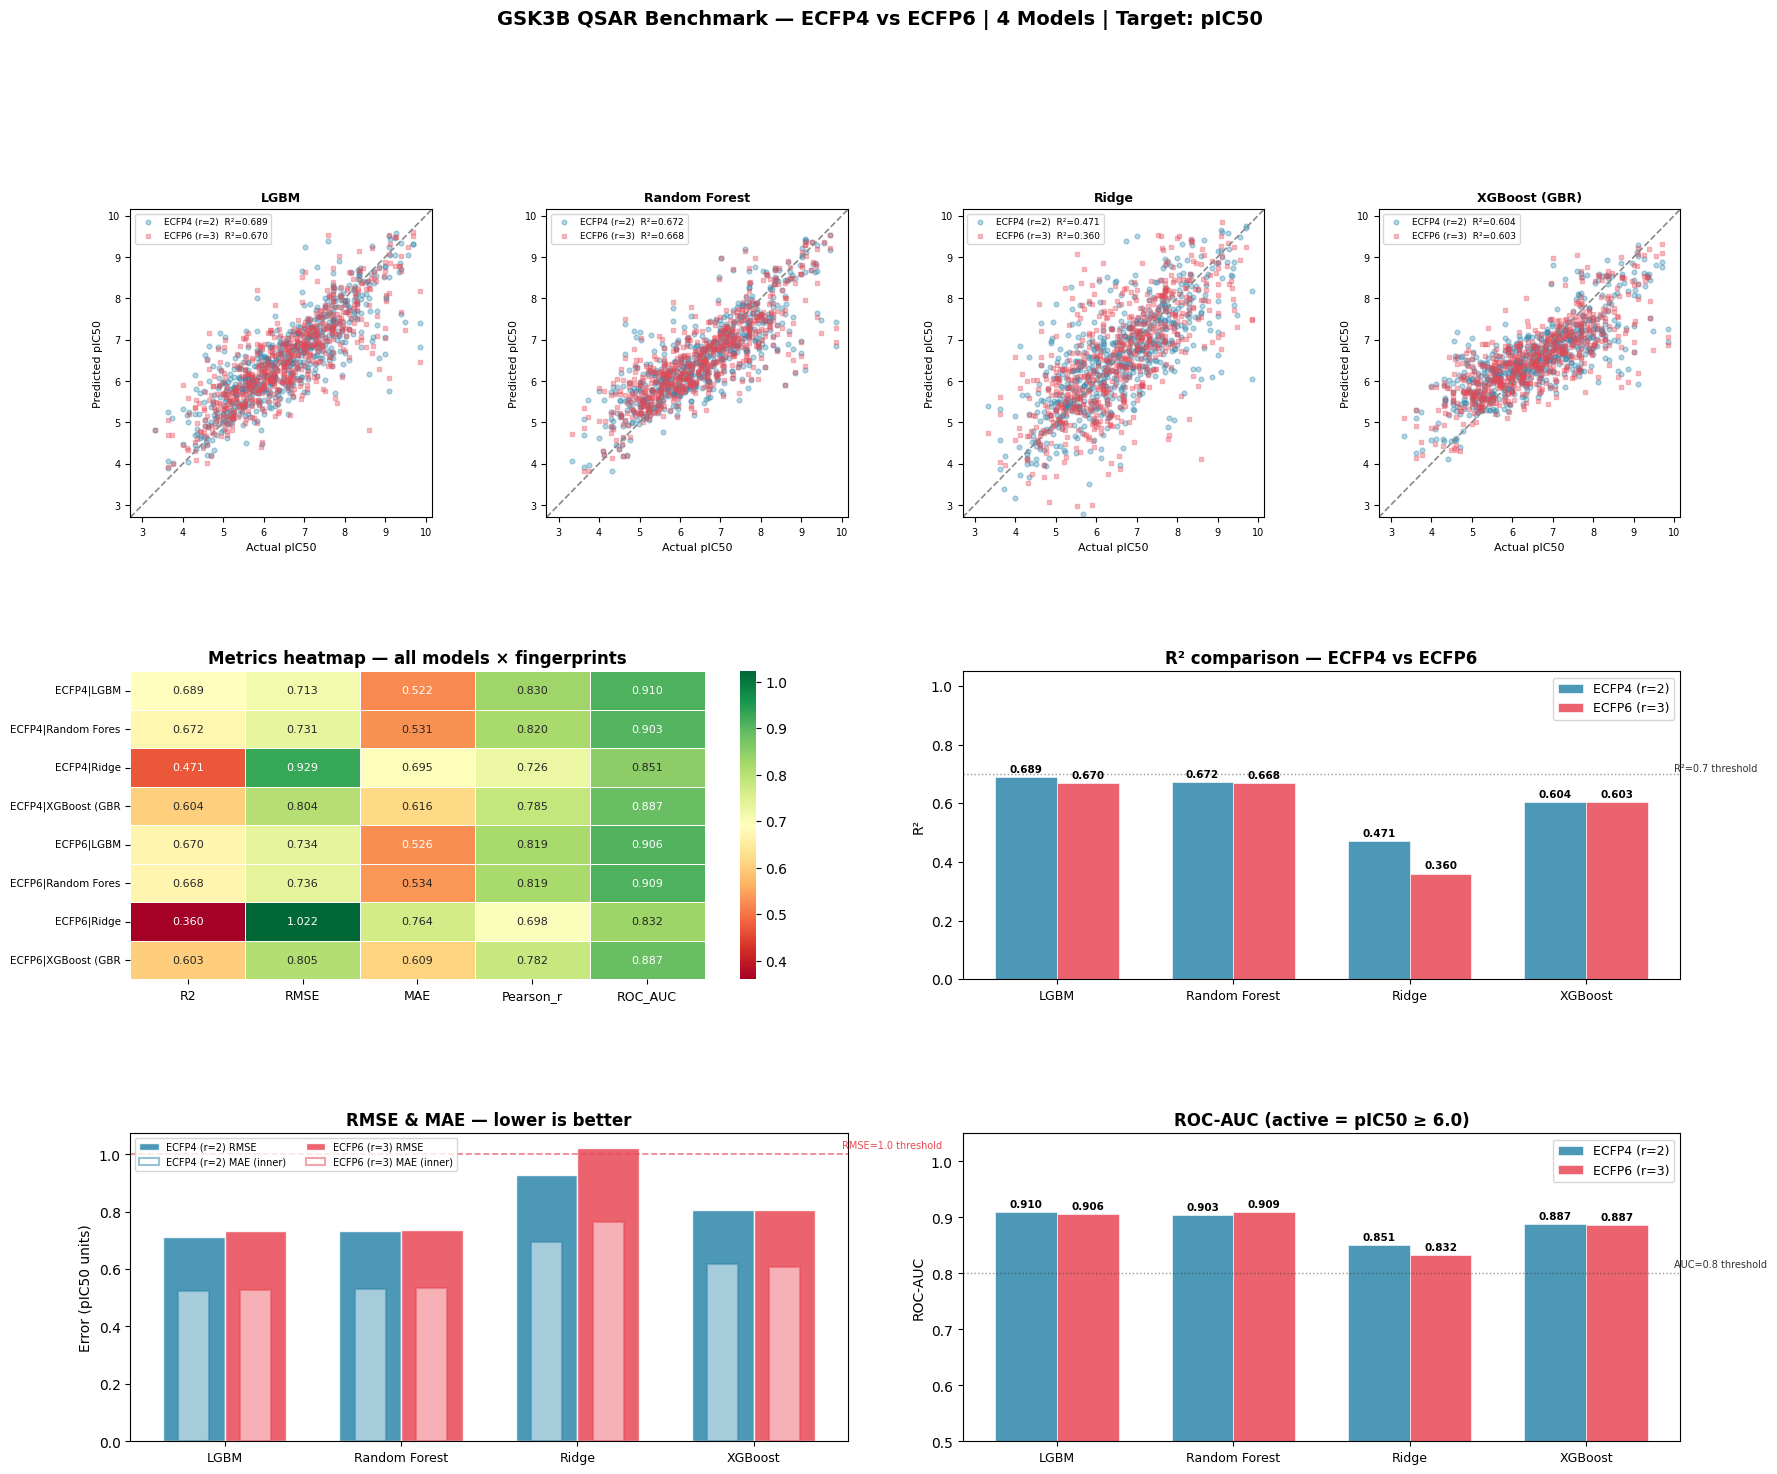

Figure saved as ecfp4_vs_ecfp6_benchmark.png


In [13]:
MODEL_NAMES  = list(MODELS.keys())
FP_NAMES     = list(FP_CONFIGS.keys())
COLORS_FP    = {"ECFP4 (r=2)": "#2E86AB", "ECFP6 (r=3)": "#E84855"}
MARKERS_FP   = {"ECFP4 (r=2)": "o",       "ECFP6 (r=3)": "s"}

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    "GSK3B QSAR Benchmark — ECFP4 vs ECFP6 | 4 Models | Target: pIC50",
    fontsize=14, fontweight='bold', y=1.005
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# ── Row 0: Predicted vs Actual (4 models, overlay ECFP4 & ECFP6) ─────────────
for col, mname in enumerate(MODEL_NAMES):
    ax = fig.add_subplot(gs[0, col])
    for fp_name in FP_NAMES:
        preds = all_results[fp_name][mname]["preds"]
        r2    = all_results[fp_name][mname]["R2"]
        ax.scatter(y_test, preds,
                   alpha=0.35, s=12,
                   color=COLORS_FP[fp_name],
                   marker=MARKERS_FP[fp_name],
                   label=f"{fp_name}  R²={r2:.3f}")
    lims = [min(y_test.min(), 3) - 0.3, max(y_test.max(), 9) + 0.3]
    ax.plot(lims, lims, '--', color='#888', lw=1.2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual pIC50", fontsize=8)
    ax.set_ylabel("Predicted pIC50", fontsize=8)
    ax.set_title(mname, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6.5, loc='upper left')
    ax.tick_params(labelsize=7)

# ── Row 1 left: Heatmap of all metrics ───────────────────────────────────────
ax_heat = fig.add_subplot(gs[1, :2])
metrics_display = ["R2", "RMSE", "MAE", "Pearson_r", "ROC_AUC"]
heat_rows, heat_labels = [], []
for fp in FP_NAMES:
    for m in MODEL_NAMES:
        r = all_results[fp][m]
        heat_rows.append([r[k] for k in metrics_display])
        heat_labels.append(f"{fp[:5]}|{m[:12]}")
heat_df = pd.DataFrame(heat_rows, columns=metrics_display, index=heat_labels)
sns.heatmap(heat_df, ax=ax_heat, annot=True, fmt=".3f", cmap="RdYlGn",
            linewidths=0.5, linecolor='white', annot_kws={"size": 8})
ax_heat.set_title("Metrics heatmap — all models × fingerprints", fontweight='bold')
ax_heat.tick_params(axis='x', labelsize=9)
ax_heat.tick_params(axis='y', labelsize=7.5)

# ── Row 1 right: R² grouped bar ──────────────────────────────────────────────
ax_r2 = fig.add_subplot(gs[1, 2:])
x = np.arange(len(MODEL_NAMES))
w = 0.35
for i, (fp_name, offset) in enumerate(zip(FP_NAMES, [-w/2, w/2])):
    vals = [all_results[fp_name][m]["R2"] for m in MODEL_NAMES]
    bars = ax_r2.bar(x + offset, vals, w,
                     color=COLORS_FP[fp_name], alpha=0.85,
                     edgecolor='white', lw=0.5, label=fp_name)
    for bar, v in zip(bars, vals):
        ax_r2.text(bar.get_x() + bar.get_width()/2,
                   v + 0.01, f"{v:.3f}",
                   ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax_r2.set_xticks(x)
ax_r2.set_xticklabels([m.replace(" (GBR)", "") for m in MODEL_NAMES], fontsize=9)
ax_r2.set_ylabel("R²"); ax_r2.set_ylim(0, 1.05)
ax_r2.set_title("R² comparison — ECFP4 vs ECFP6", fontweight='bold')
ax_r2.legend(fontsize=9)
ax_r2.axhline(0.7, color='#333', ls=':', lw=1, alpha=0.5)
ax_r2.text(len(MODEL_NAMES)-0.5, 0.71, "R²=0.7 threshold", fontsize=7, color='#333')

# ── Row 2 left: RMSE comparison ──────────────────────────────────────────────
ax_err = fig.add_subplot(gs[2, :2])
for i, (fp_name, offset) in enumerate(zip(FP_NAMES, [-w/2, w/2])):
    rmse_vals = [all_results[fp_name][m]["RMSE"] for m in MODEL_NAMES]
    mae_vals  = [all_results[fp_name][m]["MAE"]  for m in MODEL_NAMES]
    ax_err.bar(x + offset, rmse_vals, w,
               color=COLORS_FP[fp_name], alpha=0.85, edgecolor='white', label=f"{fp_name} RMSE")
    ax_err.bar(x + offset, mae_vals, w * 0.5,
               color='white', alpha=0.5, edgecolor=COLORS_FP[fp_name], lw=1.5,
               label=f"{fp_name} MAE (inner)")
ax_err.set_xticks(x)
ax_err.set_xticklabels([m.replace(" (GBR)", "") for m in MODEL_NAMES], fontsize=9)
ax_err.set_ylabel("Error (pIC50 units)")
ax_err.set_title("RMSE & MAE — lower is better", fontweight='bold')
ax_err.axhline(1.0, color='#E84855', ls='--', lw=1.2, alpha=0.7)
ax_err.text(len(MODEL_NAMES)-0.5, 1.02, "RMSE=1.0 threshold", fontsize=7, color='#E84855')
ax_err.legend(fontsize=7, ncol=2)

# ── Row 2 right: ROC-AUC ─────────────────────────────────────────────────────
ax_auc = fig.add_subplot(gs[2, 2:])
for i, (fp_name, offset) in enumerate(zip(FP_NAMES, [-w/2, w/2])):
    auc_vals = [all_results[fp_name][m]["ROC_AUC"] for m in MODEL_NAMES]
    bars = ax_auc.bar(x + offset, auc_vals, w,
                      color=COLORS_FP[fp_name], alpha=0.85,
                      edgecolor='white', lw=0.5, label=fp_name)
    for bar, v in zip(bars, auc_vals):
        ax_auc.text(bar.get_x() + bar.get_width()/2,
                    v + 0.005, f"{v:.3f}",
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax_auc.set_xticks(x)
ax_auc.set_xticklabels([m.replace(" (GBR)", "") for m in MODEL_NAMES], fontsize=9)
ax_auc.set_ylabel("ROC-AUC")
ax_auc.set_ylim(0.5, 1.05)
ax_auc.set_title(f"ROC-AUC (active = pIC50 ≥ {ACTIVE_CUTOFF})", fontweight='bold')
ax_auc.axhline(0.8, color='#333', ls=':', lw=1, alpha=0.5)
ax_auc.text(len(MODEL_NAMES)-0.5, 0.81, "AUC=0.8 threshold", fontsize=7, color='#333')
ax_auc.legend(fontsize=9)

plt.savefig("ecfp4_vs_ecfp6_benchmark.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as ecfp4_vs_ecfp6_benchmark.png")


---
## Section 7 — Results Summary & Interpretation

We print a clean summary table and draw conclusions.


In [14]:
print("=" * 85)
print(f"{'ECFP4 vs ECFP6 — SUMMARY TABLE':^85}")
print("=" * 85)
print(f"{'Model':26s} {'FP':14s} {'R²':>6} {'RMSE':>6} {'MAE':>6} {'Pearson':>8} {'AUC':>7}")
print("-" * 85)

for fp_name in FP_NAMES:
    for m in MODEL_NAMES:
        r = all_results[fp_name][m]
        marker = " ◀ best" if (
            r["R2"] == max(all_results[f][m]["R2"] for f in FP_NAMES)
            and r["R2"] == max(all_results[fp_name][mm]["R2"] for mm in MODEL_NAMES)
        ) else ""
        print(f"  {m:24s} {fp_name:14s} {r['R2']:6.3f} {r['RMSE']:6.3f} "
              f"{r['MAE']:6.3f} {r['Pearson_r']:8.3f} {r['ROC_AUC']:7.3f}{marker}")
    print()

# Delta analysis: does ECFP6 consistently beat ECFP4?
print("\nECFP6 vs ECFP4 — Delta R² (positive = ECFP6 wins)")
print("-" * 50)
ecfp6_wins = 0
for m in MODEL_NAMES:
    delta = all_results["ECFP6 (r=3)"][m]["R2"] - all_results["ECFP4 (r=2)"][m]["R2"]
    symbol = "✓ ECFP6" if delta > 0 else "✗ ECFP4"
    print(f"  {m:26s}: ΔR² = {delta:+.4f}  [{symbol}]")
    if delta > 0:
        ecfp6_wins += 1

print(f"\nECFP6 wins on {ecfp6_wins}/{len(MODEL_NAMES)} models")


                           ECFP4 vs ECFP6 — SUMMARY TABLE                            
Model                      FP                 R²   RMSE    MAE  Pearson     AUC
-------------------------------------------------------------------------------------
  LGBM                     ECFP4 (r=2)     0.689  0.713  0.522    0.830   0.910 ◀ best
  Random Forest            ECFP4 (r=2)     0.672  0.731  0.531    0.820   0.903
  Ridge                    ECFP4 (r=2)     0.471  0.929  0.695    0.726   0.851
  XGBoost (GBR)            ECFP4 (r=2)     0.604  0.804  0.616    0.785   0.887

  LGBM                     ECFP6 (r=3)     0.670  0.734  0.526    0.819   0.906
  Random Forest            ECFP6 (r=3)     0.668  0.736  0.534    0.819   0.909
  Ridge                    ECFP6 (r=3)     0.360  1.022  0.764    0.698   0.832
  XGBoost (GBR)            ECFP6 (r=3)     0.603  0.805  0.609    0.782   0.887


ECFP6 vs ECFP4 — Delta R² (positive = ECFP6 wins)
------------------------------------------------

In [15]:
print("""
INTERPRETATION GUIDE
====================

R² (coefficient of determination)
  > 0.7  → model explains most variance — good for QSAR
  0.5-0.7 → moderate — acceptable for a noisy biological dataset
  < 0.5  → poor — model barely captures the trend

RMSE (Root Mean Squared Error) — in pIC50 units
  < 0.7  → excellent (error < 5× in IC50 space)
  0.7-1.0 → acceptable (biological assays themselves have ~0.3-0.5 log variability)
  > 1.0  → poor

ROC-AUC (active vs inactive classification from regression scores)
  > 0.9  → excellent discrimination
  0.8-0.9 → good
  0.7-0.8 → moderate
  < 0.7  → poor

ECFP4 vs ECFP6 interpretation
  - If ECFP6 wins consistently: wider chemical context helps distinguish GSK3B binders
  - If ECFP4 is competitive: local functional-group features are sufficient
  - If results are mixed: the radius choice matters less than the model choice
  - Either way, showing the comparison demonstrates scientific rigor to your advisor
""")



INTERPRETATION GUIDE

R² (coefficient of determination)
  > 0.7  → model explains most variance — good for QSAR
  0.5-0.7 → moderate — acceptable for a noisy biological dataset
  < 0.5  → poor — model barely captures the trend

RMSE (Root Mean Squared Error) — in pIC50 units
  < 0.7  → excellent (error < 5× in IC50 space)
  0.7-1.0 → acceptable (biological assays themselves have ~0.3-0.5 log variability)
  > 1.0  → poor

ROC-AUC (active vs inactive classification from regression scores)
  > 0.9  → excellent discrimination
  0.8-0.9 → good
  0.7-0.8 → moderate
  < 0.7  → poor

ECFP4 vs ECFP6 interpretation
  - If ECFP6 wins consistently: wider chemical context helps distinguish GSK3B binders
  - If ECFP4 is competitive: local functional-group features are sufficient
  - If results are mixed: the radius choice matters less than the model choice
  - Either way, showing the comparison demonstrates scientific rigor to your advisor



---
## Section 8 — Apply Best Model to Unlabeled Virtual Library

After training, we apply the best-performing model to molecules that have
**no experimental IC50** — this is the virtual screening step.

The idea: rank thousands of purchasable or designed compounds by predicted
pIC50, then prioritize the top ones for experimental testing.

### Where to get unlabeled compound libraries
- **ZINC20** (`zinc20.docking.org`) — ~1.4 billion purchasable compounds
- **Enamine REAL** — ~6 billion synthetically accessible compounds
- **ChEMBL** — compounds with no GSK3B data but tested on other targets
- **Your own analogues** — SMILES of compounds you designed

Here we demonstrate with a small synthetic example library.


In [16]:
# ── For demonstration: create a small mock virtual library ───────────────────
# In real use, replace with: pd.read_csv("your_virtual_library.csv")
DEMO_LIBRARY_SMILES = [
    "CC1=CC=C(C=C1)S(=O)(=O)N1CCN(CC1)C(=O)C1=CC=C(F)C=C1",   # sulfonamide
    "O=C(NC1=CC=C(Cl)C=C1)C1=CC=NC=C1",                          # pyridine amide
    "CC(C)NC(=O)C1=CC=C(C=C1)OC1=CC=CC=C1Cl",                   # aryl ether
    "O=C(O)C1=CC=C(NC(=O)C2=CC=CC=C2)C=C1",                     # biphenyl
    "CC1=CN=CC(=C1)NC(=O)C1=CC=C(C=C1)N1CCOCC1",               # morpholine
    "O=C(NC1=CC=CC=C1F)C1=CC2=CC=CC=C2N1",                      # indole
    "CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=CC=CC=C1",               # sulfonamide 2
    "O=C(c1ccco1)N1CCN(c2ncccn2)CC1",                            # furan-piperazine
    "Cc1ccc(NC(=O)c2ccc(F)cc2)cc1C",                             # tolyl amide
    "O=C(Nc1cccc(Cl)c1)c1cnc2ccccc2c1",                         # isoquinoline
]

vlib_df = pd.DataFrame({"SMILES": DEMO_LIBRARY_SMILES,
                         "compound_id": [f"DEMO_{i+1:04d}" for i in range(len(DEMO_LIBRARY_SMILES))]})
print(f"Virtual library size: {len(vlib_df)} compounds")
vlib_df.head()


Virtual library size: 10 compounds


,SMILES,compound_id
0,CC1=CC=C(C=C1)S(=O)(=O)N1CCN(CC1)C(=O)C1=CC=C(...,DEMO_0001
1,O=C(NC1=CC=C(Cl)C=C1)C1=CC=NC=C1,DEMO_0002
2,CC(C)NC(=O)C1=CC=C(C=C1)OC1=CC=CC=C1Cl,DEMO_0003
3,O=C(O)C1=CC=C(NC(=O)C2=CC=CC=C2)C=C1,DEMO_0004
4,CC1=CN=CC(=C1)NC(=O)C1=CC=C(C=C1)N1CCOCC1,DEMO_0005


In [17]:
# ── Select best model based on R² ───────────────────────────────────────────
best_fp, best_model_name, best_r2 = None, None, -999
for fp_name in FP_NAMES:
    for m in MODEL_NAMES:
        r2 = all_results[fp_name][m]["R2"]
        if r2 > best_r2:
            best_r2 = r2
            best_fp = fp_name
            best_model_name = m

print(f"Best model: {best_model_name} with {best_fp}  (R²={best_r2:.3f})")

# ── Retrain best model on ALL data (train+test) before applying ─────────────
# Always retrain on full dataset for final predictions — don't waste data
radius = 2 if "ECFP4" in best_fp else 3
gen_best = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=2048)

# Full training data fingerprints
X_full = np.vstack([X4_train, X4_test]) if "ECFP4" in best_fp else np.vstack([X6_train, X6_test])
y_full = np.concatenate([y_train, y_test])

import copy
final_model = copy.deepcopy(MODELS[best_model_name][0])
use_scaled  = MODELS[best_model_name][1]

if use_scaled:
    scaler_final = MaxAbsScaler()
    X_full_sc = scaler_final.fit_transform(X_full.astype(np.float32))
    final_model.fit(X_full_sc, y_full)
else:
    final_model.fit(X_full, y_full)

print(f"Final model retrained on {len(y_full)} molecules (train+test combined)")


Best model: LGBM with ECFP4 (r=2)  (R²=0.689)
Final model retrained on 3167 molecules (train+test combined)


In [18]:
# ── Featurize virtual library & predict ──────────────────────────────────────
vlib_fps = []
valid_idx = []
for i, smi in enumerate(vlib_df.SMILES):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        fp = gen_best.GetFingerprint(mol)
        vlib_fps.append(np.array(fp))
        valid_idx.append(i)

X_vlib = np.array(vlib_fps, dtype=np.uint8)
print(f"Valid virtual library molecules: {len(valid_idx)}")

if use_scaled:
    X_vlib_input = scaler_final.transform(X_vlib.astype(np.float32))
else:
    X_vlib_input = X_vlib

predicted_pIC50 = final_model.predict(X_vlib_input)

# ── Build results dataframe ───────────────────────────────────────────────────
vlib_results = vlib_df.iloc[valid_idx].copy().reset_index(drop=True)
vlib_results["predicted_pIC50"] = predicted_pIC50
vlib_results["predicted_IC50_nM"] = 10 ** (9 - predicted_pIC50)  # convert back
vlib_results["priority_rank"] = vlib_results["predicted_pIC50"].rank(ascending=False).astype(int)
vlib_results = vlib_results.sort_values("priority_rank")

print(f"\n{'Rank':>5} {'Compound ID':>12} {'Pred pIC50':>12} {'Pred IC50 (nM)':>16}  SMILES[:40]")
print("-" * 90)
for _, row in vlib_results.iterrows():
    print(f"  {row.priority_rank:>3}  {row.compound_id:>12}  "
          f"{row.predicted_pIC50:>10.3f}  {row.predicted_IC50_nM:>14.1f}  "
          f"{row.SMILES[:40]}")

vlib_results.to_csv("virtual_screening_results.csv", index=False)
print("\nResults saved to virtual_screening_results.csv")


Valid virtual library molecules: 10

 Rank  Compound ID   Pred pIC50   Pred IC50 (nM)  SMILES[:40]
------------------------------------------------------------------------------------------
    1     DEMO_0005       5.882          1312.7  CC1=CN=CC(=C1)NC(=O)C1=CC=C(C=C1)N1CCOCC
    2     DEMO_0003       5.738          1828.7  CC(C)NC(=O)C1=CC=C(C=C1)OC1=CC=CC=C1Cl
    3     DEMO_0001       5.586          2595.7  CC1=CC=C(C=C1)S(=O)(=O)N1CCN(CC1)C(=O)C1
    4     DEMO_0002       5.548          2829.2  O=C(NC1=CC=C(Cl)C=C1)C1=CC=NC=C1
    5     DEMO_0006       5.491          3230.9  O=C(NC1=CC=CC=C1F)C1=CC2=CC=CC=C2N1
    6     DEMO_0007       5.477          3334.4  CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=CC=CC=C
    7     DEMO_0010       5.401          3972.2  O=C(Nc1cccc(Cl)c1)c1cnc2ccccc2c1
    8     DEMO_0009       5.151          7067.0  Cc1ccc(NC(=O)c2ccc(F)cc2)cc1C
    9     DEMO_0008       5.085          8227.0  O=C(c1ccco1)N1CCN(c2ncccn2)CC1
   10     DEMO_0004       4.897         1267

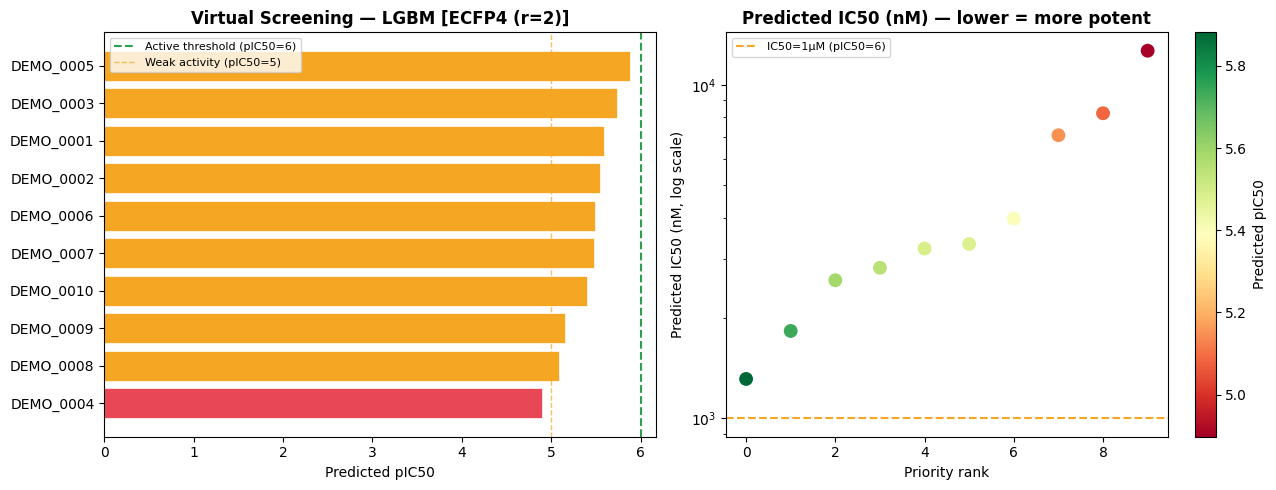

In [19]:
# ── Visualize virtual screening results ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ranked bar chart of predicted pIC50
colors_vs = ['#2E9E4F' if p >= 6 else '#E84855' if p < 5 else '#F5A623'
             for p in vlib_results.predicted_pIC50]
axes[0].barh(vlib_results.compound_id[::-1], vlib_results.predicted_pIC50[::-1],
             color=colors_vs[::-1], edgecolor='white', lw=0.5)
axes[0].axvline(6, color='#2E9E4F', ls='--', lw=1.5, label='Active threshold (pIC50=6)')
axes[0].axvline(5, color='#F5A623', ls='--', lw=1.0, alpha=0.7, label='Weak activity (pIC50=5)')
axes[0].set_xlabel("Predicted pIC50")
axes[0].set_title(f"Virtual Screening — {best_model_name} [{best_fp}]", fontweight='bold')
axes[0].legend(fontsize=8)

# Right: predicted IC50 (nM) on log scale
axes[1].scatter(range(len(vlib_results)), vlib_results.predicted_IC50_nM,
                c=vlib_results.predicted_pIC50, cmap='RdYlGn', s=80, zorder=3)
axes[1].set_yscale('log')
axes[1].axhline(1000, color='#F5A623', ls='--', lw=1.5, label='IC50=1µM (pIC50=6)')
axes[1].set_xlabel("Priority rank"); axes[1].set_ylabel("Predicted IC50 (nM, log scale)")
axes[1].set_title("Predicted IC50 (nM) — lower = more potent", fontweight='bold')
axes[1].legend(fontsize=8)
sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                             norm=plt.Normalize(vmin=vlib_results.predicted_pIC50.min(),
                                                vmax=vlib_results.predicted_pIC50.max()))
plt.colorbar(sm, ax=axes[1], label='Predicted pIC50')

plt.tight_layout()
plt.savefig("virtual_screening_plot.png", dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — Key Takeaways & Next Steps

### What this notebook demonstrated
1. **Data pipeline** — BindingDB → cleaned pIC50 → ML-ready format
2. **ECFP4 vs ECFP6** — head-to-head comparison on 4 models with full metrics
3. **Metrics** — R², RMSE, MAE, Pearson r for regression; ROC-AUC as secondary classifier check
4. **Virtual screening** — applying the trained model to prioritize new compounds

### When does ECFP6 help?
- If your molecules have **complex, extended scaffolds** (e.g. kinase inhibitors with long linkers) → ECFP6 captures more context
- If your dataset is **large** (>5000 unique molecules) → the extra bits are more reliably populated
- If ECFP4 and ECFP6 give similar results → local features are sufficient; choose ECFP4 (less collision)

### Suggested next steps for your research
| Step | What to do | Why |
|------|------------|-----|
| **Scaffold split** | Use `rdkit.Chem.Scaffolds.MurckoScaffold` for splitting | More realistic generalization estimate |
| **Chemprop** | Train D-MPNN on raw SMILES | Graph neural net, often best for small drug datasets |
| **4096-bit ECFP6** | Try `fpSize=4096` | Reduces bit collision for ECFP6 |
| **Hyperparameter tuning** | `optuna` or `GridSearchCV` on LGBM | Likely 5-15% R² improvement |
| **Applicability domain** | Flag predictions outside training chemical space | Know when to trust the model |
| **Real virtual library** | Replace demo SMILES with ZINC/Enamine compounds | Production-scale screening |
